# Quick Exploratory Data Analysis

This notebook performs a compact EDA for the cryptocurrency trading project. The goal is not to exhaust every statistical angle, but to make the modeling choices defensible: define a clean panel, create a valid next-4H target, engineer features known at time `t`, and check whether lagged, volatility, and cross-asset features are economically justified.

## Dataset integrity and gap-aware modeling frame

We first inspect the dataset structure, verify the 4-hour time grid, identify problematic assets, and create the modeling dataframe. The key methodological rule is that a 4-hour return is valid only when consecutive timestamps are exactly 4 hours apart. Long structural gaps are handled at the asset level; small residual gaps are handled locally by invalidating only the gap-crossing returns and targets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew, kurtosis
from pathlib import Path


def resolve_data_path(filename='pr15_crypto.csv') -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Unable to locate {filename} from {Path.cwd().resolve()} upwards.')


EXPECTED_FREQ = pd.Timedelta(hours=4)
DATA_PATH = resolve_data_path()
raw_df = pd.read_csv(DATA_PATH)
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])
raw_df = raw_df.sort_values(['Asset_ID', 'timestamp']).reset_index(drop=True)

print('--- DATASET STRUCTURE PREVIEW ---')
print(f'Dataset loaded from: {DATA_PATH}')
print(f'Rows: {len(raw_df):,} | Columns: {raw_df.shape[1]} | Assets: {raw_df["Asset_Name"].nunique()}')
print('\nColumns and data types:')
print(raw_df.dtypes.to_string())
print('\nFirst five rows:')
print(raw_df.head().to_string(index=False))

# Time-grid integrity by asset.
gap_report = []
gap_examples = []
for asset_id, asset_data in raw_df.groupby('Asset_ID'):
    asset_data = asset_data.sort_values('timestamp')
    asset_name = asset_data['Asset_Name'].iloc[0]
    timestamps = asset_data['timestamp'].drop_duplicates()
    expected_index = pd.date_range(timestamps.min(), timestamps.max(), freq=EXPECTED_FREQ)
    missing_timestamps = expected_index.difference(timestamps)
    deltas = timestamps.diff().dropna()
    gap_steps = (deltas / EXPECTED_FREQ).round().astype(int)

    gap_report.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_name,
        'Start': timestamps.min(),
        'End': timestamps.max(),
        'Observed points': len(timestamps),
        'Expected points': len(expected_index),
        'Missing timestamps': len(missing_timestamps),
        'Missing share': len(missing_timestamps) / len(expected_index),
        'Duplicate timestamps': int(asset_data.duplicated(['timestamp']).sum()),
        'Irregular deltas': int((deltas != EXPECTED_FREQ).sum())
    })

    for gap_end_ts, steps in gap_steps[gap_steps > 1].items():
        gap_examples.append({
            'Asset_ID': asset_id,
            'Asset_Name': asset_name,
            'Gap end': gap_end_ts,
            'Gap steps': int(steps),
            'Gap duration': steps * EXPECTED_FREQ
        })

gap_report_df = pd.DataFrame(gap_report).sort_values('Missing timestamps', ascending=False)
print('\n--- TIME-GRID SUMMARY BY ASSET ---')
print(gap_report_df.to_string(index=False))

print('\nLargest gap examples:')
gap_examples_df = pd.DataFrame(gap_examples)
if gap_examples_df.empty:
    print('No gaps larger than one 4H step.')
else:
    print(gap_examples_df.sort_values('Gap steps', ascending=False).head(10).to_string(index=False))

# Main modeling decision: exclude Maker due to structural long gaps.
EXCLUDED_ASSET_NAMES = ['Maker']
df = raw_df.loc[~raw_df['Asset_Name'].isin(EXCLUDED_ASSET_NAMES)].copy()
df = df.sort_values(['Asset_ID', 'timestamp']).reset_index(drop=True)

# Gap-aware temporal variables.
g = df.groupby('Asset_ID', group_keys=False)
df['prev_timestamp'] = g['timestamp'].shift(1)
df['next_timestamp'] = g['timestamp'].shift(-1)
df['prev_delta'] = df['timestamp'] - df['prev_timestamp']
df['next_delta'] = df['next_timestamp'] - df['timestamp']
df['valid_prev_4h'] = df['prev_delta'].eq(EXPECTED_FREQ)
df['valid_next_4h'] = df['next_delta'].eq(EXPECTED_FREQ)
df['new_segment'] = ~df['valid_prev_4h']
df['segment_id'] = df.groupby('Asset_ID')['new_segment'].cumsum().astype(int)

df['Log_Close'] = np.log(df['Close'])
df['Log_Return'] = np.where(df['valid_prev_4h'], df['Log_Close'] - g['Log_Close'].shift(1), np.nan)
df['Future_Log_Return_4H'] = np.where(df['valid_next_4h'], g['Log_Close'].shift(-1) - df['Log_Close'], np.nan)
df['Target_Up_4H'] = np.where(df['Future_Log_Return_4H'].notna(), (df['Future_Log_Return_4H'] > 0).astype(int), np.nan)

# Compact report after excluding Maker.
gap_handling_report = []
for (asset_id, asset_name), asset_data in df.groupby(['Asset_ID', 'Asset_Name']):
    segment_sizes = asset_data.groupby('segment_id').size()
    prev_gap_crossings = asset_data['prev_delta'].notna() & asset_data['prev_delta'].ne(EXPECTED_FREQ)
    next_gap_crossings = asset_data['next_delta'].notna() & asset_data['next_delta'].ne(EXPECTED_FREQ)
    gap_handling_report.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_name,
        'Rows': len(asset_data),
        'Segments': len(segment_sizes),
        'Largest segment': int(segment_sizes.max()),
        'Rows after gap': int(prev_gap_crossings.sum()),
        'Rows before gap': int(next_gap_crossings.sum()),
        'Valid returns': int(asset_data['Log_Return'].notna().sum()),
        'Valid targets': int(asset_data['Future_Log_Return_4H'].notna().sum())
    })

gap_handling_report_df = pd.DataFrame(gap_handling_report).sort_values(['Rows before gap', 'Rows after gap'], ascending=False)
print('\n--- MODELING DATASET AFTER GAP HANDLING ---')
print(f'Excluded assets: {", ".join(EXCLUDED_ASSET_NAMES)}')
print(f'Rows after exclusion: {len(df):,} | Assets after exclusion: {df["Asset_Name"].nunique()}')
print(gap_handling_report_df.to_string(index=False))
print('\nOverall valid supervised rows:')
print(f'Valid current 4H returns: {df["Log_Return"].notna().sum():,} / {len(df):,}')
print(f'Valid future 4H targets: {df["Future_Log_Return_4H"].notna().sum():,} / {len(df):,}')
print(f'Residual rows before gaps invalidated for target: {(df["next_delta"].notna() & df["next_delta"].ne(EXPECTED_FREQ)).sum():,}')

--- DATASET STRUCTURE PREVIEW ---
Dataset loaded from: /Users/typ4ndi3_/Desktop/All I Need/Nova SBE/Courses/Introduction to Machine Learning/Project/Cryptocurrency/Machine-Learning-Group-Poject/pr15_crypto.csv
Rows: 104,324 | Columns: 12 | Assets: 14

Columns and data types:
Unnamed: 0             int64
Asset_ID               int64
timestamp     datetime64[ns]
Count                float64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume               float64
VWAP                 float64
Weight               float64
Asset_Name            object

First five rows:
 Unnamed: 0  Asset_ID           timestamp  Count   Open   High    Low  Close    Volume     VWAP   Weight   Asset_Name
          0         0 2018-01-01 00:00:00 3272.0 8.5300 8.5300 8.1305 8.3401 136150.46 8.327702 4.304065 Binance Coin
          1         0 2018-01-01 04:00:00 3231.0 8.3612 8.7000 8.3410 8.3600 100304.70 8.485586 4.304065 Binance Coin
    

## Integrity takeaway

`Expected points` is computed separately for each asset between its own first and last timestamp, so assets that start later naturally have fewer expected observations. Maker is the only asset with structural missingness: it has thousands of missing timestamps and long gaps lasting several weeks. It is therefore excluded from the main experiment. The remaining assets are kept, and their small residual gaps are handled locally by setting only gap-crossing returns or targets to missing. This preserves almost all useful data while keeping the 4-hour target mathematically valid.

## Compact feature and target diagnostics

We now create a compact feature set known at time `t`. It includes own-asset return dynamics, rolling volatility, candle/VWAP pressure, liquidity, and market-wide crypto information. Redundant candidates identified earlier, such as raw market return versus leave-one-out market return or candle return versus current close-to-close return, are intentionally omitted.

In [2]:
print('\n--- FEATURE AND TARGET DIAGNOSTIC DATASET ---')

# VWAP validation.
vwap_finite = np.isfinite(df['VWAP'])
vwap_inside_range = df['VWAP'].between(df['Low'], df['High'], inclusive='both')
df['VWAP_Clean'] = df['VWAP'].where(vwap_finite & vwap_inside_range, np.nan)
invalid_vwap_rows = (~vwap_finite | ~vwap_inside_range).sum()

# Features known at time t.
df['High_Low_Range'] = (df['High'] - df['Low']) / df['Open']
df['VWAP_Deviation'] = (df['Close'] - df['VWAP_Clean']) / df['Close']
df['Log_Volume'] = np.log1p(df['Volume'])
df['Log_Count'] = np.log1p(df['Count'])

seg = df.groupby(['Asset_ID', 'segment_id'], group_keys=False)
df['Return_Current_4H'] = df['Log_Return']
df['Return_Lag_1'] = seg['Log_Return'].shift(1)
df['Return_Lag_2'] = seg['Log_Return'].shift(2)
df['Return_Lag_3'] = seg['Log_Return'].shift(3)
df['Rolling_Return_Mean_6'] = seg['Log_Return'].transform(lambda s: s.rolling(6, min_periods=4).mean())
df['Rolling_Volatility_6'] = seg['Log_Return'].transform(lambda s: s.rolling(6, min_periods=4).std())
df['Rolling_Volatility_42'] = seg['Log_Return'].transform(lambda s: s.rolling(42, min_periods=24).std())
df['Log_Count_Change_1'] = seg['Log_Count'].diff(1)

# Market features at time t.
return_pivot = df.pivot(index='timestamp', columns='Asset_ID', values='Log_Return')
market_sum = return_pivot.sum(axis=1, skipna=True)
market_count = return_pivot.count(axis=1)
btc_return = return_pivot[1].rename('BTC_Return')
eth_return = return_pivot[6].rename('ETH_Return')

df['BTC_Return'] = df['timestamp'].map(btc_return)
df['ETH_Return'] = df['timestamp'].map(eth_return)
df['Market_Return_Ex_Asset'] = (df['timestamp'].map(market_sum) - df['Log_Return']) / (df['timestamp'].map(market_count) - 1)

candidate_features = [
    'Return_Current_4H', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3',
    'Rolling_Return_Mean_6', 'Rolling_Volatility_6', 'Rolling_Volatility_42',
    'High_Low_Range', 'VWAP_Deviation', 'Log_Volume', 'Log_Count_Change_1',
    'Market_Return_Ex_Asset', 'BTC_Return', 'ETH_Return'
]

diagnostic_df = df[df['Future_Log_Return_4H'].notna()].copy()

print(f'Invalid VWAP rows after excluding Maker: {invalid_vwap_rows:,}')
print(f'Diagnostic rows with valid next-4H target: {len(diagnostic_df):,}')
print(f'Target up-rate: {diagnostic_df["Target_Up_4H"].mean():.4f}')

print('\nTarget balance by asset:')
target_balance_by_asset = (
    diagnostic_df.groupby(['Asset_ID', 'Asset_Name'])['Target_Up_4H']
    .agg(n='size', up_rate='mean')
    .reset_index()
    .sort_values('Asset_ID')
)
print(target_balance_by_asset.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nFeature missingness:')
feature_missingness = (
    diagnostic_df[candidate_features].isna().mean().sort_values(ascending=False)
    .rename('missing_share').reset_index().rename(columns={'index': 'feature'})
)
print(feature_missingness.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


--- FEATURE AND TARGET DIAGNOSTIC DATASET ---
Invalid VWAP rows after excluding Maker: 0
Diagnostic rows with valid next-4H target: 101,220
Target up-rate: 0.5043

Target balance by asset:
 Asset_ID       Asset_Name    n  up_rate
        0     Binance Coin 8133   0.5125
        1          Bitcoin 8153   0.5156
        2     Bitcoin Cash 8153   0.4980
        3          Cardano 7515   0.5006
        4         Dogecoin 5351   0.4917
        5           EOS.IO 8153   0.5045
        6         Ethereum 8153   0.5082
        7 Ethereum Classic 8153   0.4983
        8             IOTA 7381   0.4993
        9         Litecoin 8153   0.5013
       11           Monero 8149   0.5144
       12          Stellar 7841   0.5018
       13             TRON 7932   0.5049

Feature missingness:
               feature  missing_share
 Rolling_Volatility_42         0.0074
          Return_Lag_3         0.0014
 Rolling_Return_Mean_6         0.0014
  Rolling_Volatility_6         0.0014
          Return_Lag_2  

## Feature takeaway

The target is almost perfectly balanced overall and by asset, so the classification task does not require aggressive class balancing. Feature missingness is low and mainly caused by lagged or rolling variables needing enough past observations inside each continuous segment. The compact feature set is therefore suitable as the starting point for leakage-safe modeling, with imputation handled later inside training pipelines.

## Signal diagnostics: dependence, cross-asset structure, and feature-target association

This final EDA block checks whether the compact feature set is economically justified. We summarize own-asset dependence, volatility clustering, cross-asset co-movement, and feature-target association. These diagnostics guide the modeling feature set but do not replace temporal cross-validation.


--- COMPACT SIGNAL DIAGNOSTICS ---


Per-asset dependence summary:
 Asset_ID       Asset_Name  Rows  Up rate  Return ACF1  Abs return ACF1  Ljung p20  Excess kurtosis
        0     Binance Coin  8133   0.5125     -0.02387           0.2159  2.423e-19            12.23
        1          Bitcoin  8153   0.5156     -0.03225           0.2321  1.445e-21            13.63
        2     Bitcoin Cash  8153    0.498     -0.02883            0.247  4.844e-15            10.95
        3          Cardano  7515   0.5006     -0.03081           0.2049  2.646e-15            7.102
        4         Dogecoin  5351   0.4917      0.01698           0.4362  1.376e-79            102.9
        5           EOS.IO  8153   0.5045     -0.02049           0.2441  4.119e-18            12.47
        6         Ethereum  8153   0.5082     -0.03021            0.237  1.147e-19            9.945
        7 Ethereum Classic  8153   0.4983     -0.07407            0.287  2.266e-25            10.62
        8             IOTA  7381   0.4993     -0.05642           0.226

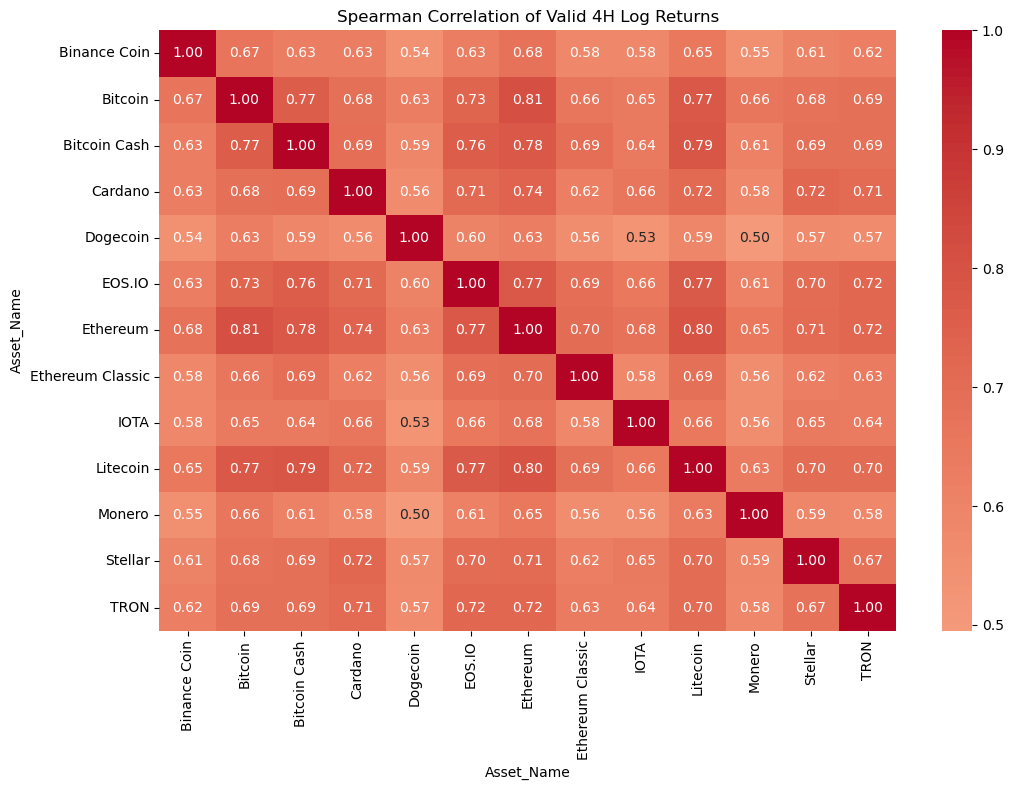


Cross-asset correlation summary:
count    78.000000
mean      0.656756
std       0.069657
min       0.495244
25%       0.609929
50%       0.656623
75%       0.700133
max       0.811506

Top 10 contemporaneous cross-asset correlations:
     Asset 1      Asset 2  Spearman rho
     Bitcoin     Ethereum        0.8115
    Ethereum     Litecoin        0.7956
Bitcoin Cash     Litecoin        0.7861
Bitcoin Cash     Ethereum        0.7797
      EOS.IO     Ethereum        0.7742
     Bitcoin     Litecoin        0.7740
      EOS.IO     Litecoin        0.7671
     Bitcoin Bitcoin Cash        0.7653
Bitcoin Cash       EOS.IO        0.7641
     Cardano     Ethereum        0.7406



Highly correlated feature pairs |rho| >= 0.70:
             Feature 1              Feature 2  Spearman rho
Market_Return_Ex_Asset             ETH_Return        0.8762
Market_Return_Ex_Asset             BTC_Return        0.8420
            BTC_Return             ETH_Return        0.8131
     Return_Current_4H Market_Return_Ex_Asset        0.7733
     Return_Current_4H             ETH_Return        0.7434
     Return_Current_4H         VWAP_Deviation        0.7372
     Return_Current_4H             BTC_Return        0.7191



Top feature-target associations:
               Feature      n  Spearman IC  Corr with up target
        VWAP_Deviation 101220     -0.08271             -0.07884
     Return_Current_4H 101183     -0.06870             -0.06169
            BTC_Return 101212     -0.06391             -0.05401
 Rolling_Return_Mean_6 101077     -0.05076             -0.04981
            ETH_Return 101212     -0.05042             -0.04694
Market_Return_Ex_Asset 101183     -0.04623             -0.04620
          Return_Lag_3 101077      0.02494              0.01586
  Rolling_Volatility_6 101077      0.01666              0.01570
          Return_Lag_2 101112      0.01269              0.00970
          Return_Lag_1 101147     -0.01054             -0.01111
    Log_Count_Change_1 101183     -0.00942             -0.01036
        High_Low_Range 101220      0.00905              0.00408


In [3]:
print('\n--- COMPACT SIGNAL DIAGNOSTICS ---')


def weighted_segment_autocorr(asset_data, column, lag):
    values, weights = [], []
    for _, segment in asset_data.groupby('segment_id'):
        x = segment[column].replace([np.inf, -np.inf], np.nan).dropna()
        if len(x) > lag + 5:
            rho = x.autocorr(lag=lag)
            if pd.notna(rho):
                values.append(rho)
                weights.append(len(x) - lag)
    return np.average(values, weights=weights) if values else np.nan


def ljung_pvalue(asset_data, lag=20):
    segment_sizes = asset_data.groupby('segment_id').size()
    longest_segment_id = segment_sizes.idxmax()
    x = asset_data.loc[asset_data['segment_id'] == longest_segment_id, 'Log_Return'].dropna()
    if len(x) <= lag + 5:
        return np.nan
    return acorr_ljungbox(x, lags=[lag], return_df=True).loc[lag, 'lb_pvalue']

asset_diag = []
for (asset_id, asset_name), asset_data in diagnostic_df.groupby(['Asset_ID', 'Asset_Name']):
    temp = asset_data.copy()
    temp['Abs_Log_Return'] = temp['Log_Return'].abs()
    asset_diag.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_name,
        'Rows': len(asset_data),
        'Up rate': asset_data['Target_Up_4H'].mean(),
        'Return ACF1': weighted_segment_autocorr(asset_data, 'Log_Return', 1),
        'Abs return ACF1': weighted_segment_autocorr(temp, 'Abs_Log_Return', 1),
        'Ljung p20': ljung_pvalue(asset_data, lag=20),
        'Excess kurtosis': kurtosis(asset_data['Log_Return'].dropna())
    })
asset_diag_df = pd.DataFrame(asset_diag).sort_values('Asset_ID')
print('Per-asset dependence summary:')
print(asset_diag_df.to_string(index=False, float_format=lambda x: f'{x:.4g}'))

# Cross-asset co-movement.
asset_return_pivot = df.pivot(index='timestamp', columns='Asset_Name', values='Log_Return')
cross_asset_corr = asset_return_pivot.corr(method='spearman', min_periods=1000)
plt.figure(figsize=(11, 8))
sns.heatmap(cross_asset_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Spearman Correlation of Valid 4H Log Returns')
plt.tight_layout()
plt.show()

corr_pairs = []
cols = list(cross_asset_corr.columns)
for i, left in enumerate(cols):
    for right in cols[i+1:]:
        rho = cross_asset_corr.loc[left, right]
        if pd.notna(rho):
            corr_pairs.append({'Asset 1': left, 'Asset 2': right, 'Spearman rho': rho})
corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Spearman rho', ascending=False)
print('\nCross-asset correlation summary:')
print(corr_pairs_df['Spearman rho'].describe().to_string())
print('\nTop 10 contemporaneous cross-asset correlations:')
print(corr_pairs_df.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Feature redundancy and feature-target association.
feature_data = diagnostic_df[candidate_features + ['Future_Log_Return_4H', 'Target_Up_4H']].replace([np.inf, -np.inf], np.nan)
feature_corr = feature_data[candidate_features].corr(method='spearman', min_periods=1000)
high_corr_pairs = []
for i, left in enumerate(candidate_features):
    for right in candidate_features[i+1:]:
        rho = feature_corr.loc[left, right]
        if pd.notna(rho) and abs(rho) >= 0.70:
            high_corr_pairs.append({'Feature 1': left, 'Feature 2': right, 'Spearman rho': rho, 'abs rho': abs(rho)})
high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values('abs rho', ascending=False)
print('\nHighly correlated feature pairs |rho| >= 0.70:')
if high_corr_pairs_df.empty:
    print('No feature pairs above threshold.')
else:
    print(high_corr_pairs_df.drop(columns='abs rho').to_string(index=False, float_format=lambda x: f'{x:.4f}'))

assoc = []
for feature in candidate_features:
    temp = feature_data[[feature, 'Future_Log_Return_4H', 'Target_Up_4H']].dropna()
    assoc.append({
        'Feature': feature,
        'n': len(temp),
        'Spearman IC': temp[feature].corr(temp['Future_Log_Return_4H'], method='spearman'),
        'Corr with up target': temp[feature].corr(temp['Target_Up_4H'], method='pearson')
    })
assoc_df = pd.DataFrame(assoc).assign(abs_ic=lambda x: x['Spearman IC'].abs()).sort_values('abs_ic', ascending=False)
print('\nTop feature-target associations:')
print(assoc_df.drop(columns='abs_ic').head(12).to_string(index=False, float_format=lambda x: f'{x:.5f}'))

## EDA takeaways for modeling

The EDA leads to three modeling decisions. First, the target should be the next valid 4-hour return direction, not the raw future price. Second, the main modeling dataset should exclude Maker but keep the other 13 assets with gap-aware return and target construction. Third, the feature set should be compact and economically motivated: own recent returns, rolling volatility, candle/VWAP pressure, liquidity, and market-wide crypto returns.

The diagnostics show weak but plausible predictive signals, mostly short-term mean reversion and market/candle-position effects. Cross-asset contemporaneous correlations are high, so BTC/ETH/market features are justified, but their lead-lag association with the next candle is weak and should be validated by models rather than assumed. The next section should build the final `model_df`, define a temporal train/validation/test split, and compare at least five classical ML models plus a neural network using leakage-safe pipelines.